In [ ]:
# 의료 기초 데이터 분석 미니 프로젝트
# numpy + pandas + Matplotlib

test


In [1]:
#==============================
# [A] 라이브러리 import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#==============================
# [B] pandas출력 옵션(선택)
pd.set_option('display.width', 140) # 너비 140정도로 깨지지 않게 조정
pd.set_option('display.max_columns', 60) # 최대 60개까지 보여줌
pd.set_option('display.max_rows', 200) # 200개 까지 보여줌

#==============================
# [1] 데이터 준비

data = {
    "측정일": [
        "2026-02-01","2026-02-01","2026-02-02","2026-02-02","2026-02-03",
        "2026-02-03","2026-02-04","2026-02-04","2026-02-05","2026-02-05",
        "2026-02-06","2026-02-06","2026-02-07","2026-02-07","2026-02-08"
    ],
    "환자ID": [
        "P001","P002","P003","P004","P005",
        "P006","P007","P008","P009","P010",
        "P011","P012","P013","P014","P015"
    ],
    "성별": ["F","M","M","F","F","M","M","F","F","M","F","M","M","F","F"],
    "나이":  [25, 31, 44, np.nan, 52, 39, 28, 33, 47, 61, 29, 42, np.nan, 36, 55],
    "키":    ["162cm","175cm","168cm","160cm","158cm","180cm","172cm","165cm","170cm","177cm","159cm","174cm","169cm","163cm","157cm"],
    "몸무게": ["54kg","78kg","70kg","52kg","60kg","90kg","68kg","58kg","73kg","82kg","50kg","76kg","71kg","57kg","66kg"],
    "SBP(수축기)": [108, 135, 142, 118, 150, 130, 125, 112, 140, 160, 105, 138, 145, 120, 155],
    "DBP(이완기)": [ 70,  88,  92,  75,  95,  85,  80,  72,  90, 100,  68,  89,  96,  78,  97],
    "심박수":      [72,  84,  90,  68,  95,  78,  70,  75,  88,  92,  66,  80,  86,  73,  89],
    "공복혈당":    [92,  110, 125,  98, 130, np.nan, 105,  90, 118, 140,  88, 112, 128, 100, np.nan],
    "흡연":        ["N","Y","Y","N","N","Y","N","N","Y","Y","N","Y","Y","N","N"],
    "운동빈도(주)": [3, 1, 0, 2, np.nan, 1, 4, 2, 1, 0, 5, 1, 0, 3, np.nan],
}

df = pd.DataFrame(data) # DataFrame형태로 변경


#==============================
# [2] 데이터 탐색

print("[head()]")
print(df.head())
print("\n[info]") # 데이터구조 확인
print(df.info())
print("\n[describe()]") # 숫자 컬럼 요약
num_cols = ["나이", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)"]
print(df[num_cols].describe())


[head()]
          측정일  환자ID 성별    나이      키   몸무게  SBP(수축기)  DBP(이완기)  심박수   공복혈당 흡연  운동빈도(주)
0  2026-02-01  P001  F  25.0  162cm  54kg       108        70   72   92.0  N      3.0
1  2026-02-01  P002  M  31.0  175cm  78kg       135        88   84  110.0  Y      1.0
2  2026-02-02  P003  M  44.0  168cm  70kg       142        92   90  125.0  Y      0.0
3  2026-02-02  P004  F   NaN  160cm  52kg       118        75   68   98.0  N      2.0
4  2026-02-03  P005  F  52.0  158cm  60kg       150        95   95  130.0  N      NaN

[info]
<class 'pandas.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 12 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   측정일       15 non-null     str    
 1   환자ID      15 non-null     str    
 2   성별        15 non-null     str    
 3   나이        13 non-null     float64
 4   키         15 non-null     str    
 5   몸무게       15 non-null     str    
 6   SBP(수축기)  15 non-null     int64  
 7   DBP(이완기)  15 non-nu

In [2]:
#==============================
# [3] 데이터 정제 및 변환

#==============================
# 3-1 타입변환 : 날짜 문자열 -> datetime
# pd.to_datetime() : 문자열을 날짜/시간 타입으로 변환
df["측정일"] = pd.to_datetime(df["측정일"])

# 3-2 단위 제거 : "170cm" -> 170, "65kg" -> 65
# str.replace() : 문자열 치환(여기서는 단위 제거)
# astype(int) : 숫자형으로 변환
df["키_cm"] = df["키"].str.replace("cm", "", regex=False).astype(int) # regex=False 단순 문자열 제거
df["몸무게_kg"] = df["몸무게"].str.replace("kg", "", regex=False).astype(int) # regex=False 단순 문자열 제거

# 원본 키, 몸무게 컬럼은 "문자열"이라 분석에 불리하므로 보통 숫자형 컬럼만 쓰는 편

# 3-3 결측치 확인
# print("[결측치 개수 확인]")
# print(df.isnull().sum())

# 3-4 결측치 처리(예시)
# 결측치 처리 방식은 상황에 따라 다름 -> 여러가지 방식으로 채움
# 나이 -> 평균 
# 공복혈당 -> 중앙값(극단값 영향 줄이고 싶을떄)
# 운동빈도(주) -> 0으로 채움 (운동기록이 없으면 0으로 가정)
df["나이"] = df["나이"].fillna(df["나이"].mean())
df["공복혈당"] = df["공복혈당"].fillna(df["공복혈당"].median())
df["운동빈도(주)"] = df["운동빈도(주)"].fillna(0)
# print(df.isnull().sum())

# 3-5 파생 컬럼 생성(변환)
# 기존 컬럼 이용해서 새로운 컬럼 만드는 단계

# BMI = 몸무게(kg) / (키(m)^2)
df["키_m"] = df["키_cm"] / 100
df["BMI"] = df["몸무게_kg"] / (df["키_m"] ** 2)
# print(df["BMI"])

# 맥박압(pp) = SBP - DBP(혈관 탄성/압력 차이를 보는 간단 지표)
df["맥박압_pp"] = df["SBP(수축기)"] - df["DBP(이완기)"]
# print(df["맥박압_pp"])

# 평균동맥압("MAP") = (SBP + 2*DBP) / 3 (기초적인 참고 지표)
df["평균동맥압_MAP"] = (df["SBP(수축기)"] + 2 * df["DBP(이완기)"]) / 3
# print(df["평균동맥압_MAP"])

# 3-6 범주화(카테고리 만들기) : 혈압 단계 분류
# 기준 (간단)
# 정상 : SBP < 120 and DBP < 80
# 주의(상승) : SBP 120 ~ 129 and DBP < 80
# 고혈압 1기 : SBP 130 ~ 139 or DBP 80 ~ 89
# 고혈압 2기 : SBP >= 140 or DBP >= 90

def bp_category(sbp, dbp):
    if sbp < 120 and dbp < 80:
        return "정상"
    elif 120 <= sbp <= 129 and dbp < 80:
        return "주의(상승)"
    elif 130 <= sbp <= 139 or 80 <= dbp <= 89:
        return "고혈압1기"
    elif sbp >= 140 or dbp >= 90:
        return "고혈압2기"
    else:
        return "기타"
    
# apply() : 행 단위로 함수를 적용할 떄 자주 사용
# lambda row : 익명 함수(이름없는 함수)
# lambda 입력값 : 계산식
# axis=1 : 가로로 뭉개 => 행별 계산
df["혈압분류"] = df.apply(lambda row: bp_category(row["SBP(수축기)"], row["DBP(이완기)"]), axis=1)
# print(df["혈압분류"])

# 3-7 범주화 : BMI 단계 분류 (간단 예시)
# BMI 분류
# 저체중 : < 18.5
# 정상 18.5 ~ 22.9
# 과체중 : 23.0 ~ 24.9
# 비만 : >= 25.0

def bmi_category(bmi):
    if bmi < 18.5:
        return "저체중"
    elif 18.5 <= bmi <= 22.9:
        return "정상"
    elif 23.0 <= bmi <= 24.9:
        return "과체중"
    elif bmi >= 25.0:
        return "비만"
    else:
        return "기타"
    
# df["BMI분류"] = df.apply(lambda row: bmi_category(row["BMI"]), axis=1)
df["BMI분류"] = df["BMI"].apply(bmi_category)
# print(df["BMI분류"])

print("[정제/변환 결과 미리보기]")
show_cols = ["측정일","환자ID","성별","나이","키_cm","몸무게_kg","SBP(수축기)","DBP(이완기)","공복혈당","운동빈도(주)","BMI","혈압분류","BMI분류"]
print(df[show_cols].head(10))

[정제/변환 결과 미리보기]
         측정일  환자ID 성별         나이  키_cm  몸무게_kg  SBP(수축기)  DBP(이완기)   공복혈당  운동빈도(주)        BMI   혈압분류 BMI분류
0 2026-02-01  P001  F  25.000000   162      54       108        70   92.0      3.0  20.576132     정상    정상
1 2026-02-01  P002  M  31.000000   175      78       135        88  110.0      1.0  25.469388  고혈압1기    비만
2 2026-02-02  P003  M  44.000000   168      70       142        92  125.0      0.0  24.801587  고혈압2기   과체중
3 2026-02-02  P004  F  40.153846   160      52       118        75   98.0      2.0  20.312500     정상    정상
4 2026-02-03  P005  F  52.000000   158      60       150        95  130.0      0.0  24.034610  고혈압2기   과체중
5 2026-02-03  P006  M  39.000000   180      90       130        85  110.0      1.0  27.777778  고혈압1기    비만
6 2026-02-04  P007  M  28.000000   172      68       125        80  105.0      4.0  22.985398  고혈압1기    기타
7 2026-02-04  P008  F  33.000000   165      58       112        72   90.0      2.0  21.303949     정상    정상
8 2026-02-05  P009  F

In [12]:
#==============================
# [4] 데이터 분석

#==============================
# 4-1 최고/최저 : BMI가 가장 높은/낮은 사람

# idx : index라고 생각
max_bmi_row = df.loc[df["BMI"].idxmax()] # 최댓값 위치 반환. BMI가 최고인 행 전체를 가져오는 것
min_bmi_row = df.loc[df["BMI"].idxmin()] # 최솟값 위치 반환

print("[BMI 최고]")
print(max_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]]) # 여러개의 열을 가져오므로 [[]] 사용
print("[BMI 최저]")
print(min_bmi_row[["환자ID", "성별", "나이", "키_cm", "몸무게_kg", "BMI", "BMI분류"]])

# 4-2 혈압 분류별 평균 지표
# groupby : 혈압분류별로 데이터를 묶겠다
# sort_values(기준) : 정렬
# ascending : False : 내림차순/ True : 오름차순
# 혈압분류별로 해당 컬럼들 평균을 묶어서 SBP 기준으로 내림차순으로 저장
# 혈압분류 종류들에서 선택한 컬럼들의 각각의 평균을 냄 -> SBP 값 기준 내림차순으로 저장
# 예를들어 정상인것들 끼리 선택한 컬럼들의 각각 평균냄
bp_group = df.groupby("혈압분류")[["SBP(수축기)", "DBP(이완기)", "맥박압_pp", "평균동맥압_MAP", "BMI", "공복혈당"]].mean().sort_values("SBP(수축기)", ascending=False)
print("[혈압 분류별 평균]")
print(bp_group)

# 4-3 성별 평균 비교
# 예를들어 F면 F인 것들의 해당 컬럼 각각 평균냄
gender_mean = df.groupby("성별")[["SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "BMI", "운동빈도(주)"]].mean()
print("[성별 별 평균]")
print(gender_mean)

# 4-4 연령대 만들기 + 그룹 평균
# 나이대는 분석에서 자주 사용
# pd.cut() : 숫자를 구간으로 나눠 범주형 컬럼 생성

bins = [0, 29, 39, 49, 59, 120] # 기준
labels = ["20대", "30대", "40대", "50대", "60대 이상"] # 이름표
df["나이대"] = pd.cut(df["나이"], bins=bins, labels=labels, right=True) # 범주화 
# right=True : 구간의 포함 기준 -> [29, 39] : 29 < 나이 <=39
age_group = df.groupby("나이대")[["SBP(수축기)", "DBP(이완기)", "공복혈당", "BMI"]].mean()
print("[나이대별 평균]")
print(age_group)


# 4-5 상관관계 (수치형 컬럼)
# 각 컬럼끼리 상관관계 -> 행, 열에 각 컬럼이 들어가고, 만약 나이라면 나이와 나이, 나이와 키, 이렇게 상관관계를 보여줌
# 서로 얼마나 같이 움직이는지
# corr() : 상관계수 (-1 ~ 1)
# 1에 가까울수록 같이 오르는 경향(양의 상관)
# -1에 가까울수록 반대로 움직이는 경향(음의 상관)
# 0에 가까울수록 관계가 거의 없음(무상관에 가까움)
corr_cols = ["나이", "키_cm", "몸무게_kg", "SBP(수축기)", "DBP(이완기)", "심박수", "공복혈당", "운동빈도(주)", "BMI", "맥박압_pp", "평균동맥압_MAP"]
corr_df = df[corr_cols].corr()

print("[상관관계]")
print(corr_df)

# 4-6 조건 필터링
# 예시 위험군 조건
# 혈압 : 고혈압 2기
# 공복혈당 : 126이상(당뇨 기준으로 자주 언급되는 구간)
# BMI : 25이상
# 해당 조건 중 하나라도 True면 관심 대상 가정

# 조건에 해당하는 행만 복사해서 가져옴 -> 행만 복사한 것이므로 각각의 컬럼은 다 있음
# risk_df안에는 조건에 해당하는 행만 DataFrame으로 들어있음
risk_df = df[
    (df["혈압분류"] == "고혈압2기") | 
    (df["공복혈당"] >= 126) | 
    (df["BMI"] >= 25.0) # ,
    # [선택한 행만 가져올 떄 사용]
].copy()

print("risk_df")
print(risk_df)

print("[관심대상 목록]")
print(risk_df[["환자ID", "성별", "나이", "SBP(수축기)", "DBP(이완기)", "혈압분류", "공복혈당", "BMI", "BMI분류", "운동빈도(주)"]])

[BMI 최고]
환자ID           P006
성별                M
나이             39.0
키_cm            180
몸무게_kg           90
BMI       27.777778
BMI분류            비만
Name: 5, dtype: object
[BMI 최저]
환자ID           P011
성별                F
나이             29.0
키_cm            159
몸무게_kg           50
BMI       19.777699
BMI분류            정상
Name: 10, dtype: object
[혈압 분류별 평균]
          SBP(수축기)  DBP(이완기)     맥박압_pp   평균동맥압_MAP        BMI        공복혈당
혈압분류                                                                      
고혈압2기   148.666667     95.00  53.666667  112.888889  25.317425  125.166667
고혈압1기   132.000000     85.50  46.500000  101.000000  25.333739  109.250000
주의(상승)  120.000000     78.00  42.000000   92.000000  21.453574  100.000000
정상      110.750000     71.25  39.500000   84.416667  20.492570   92.000000
[성별 별 평균]
      SBP(수축기)  DBP(이완기)        심박수        공복혈당        BMI  운동빈도(주)
성별                                                                 
F   126.000000    80.625  78.250000  103.250000

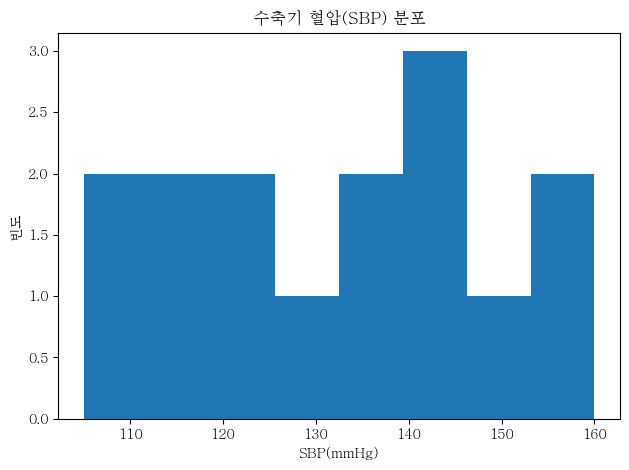

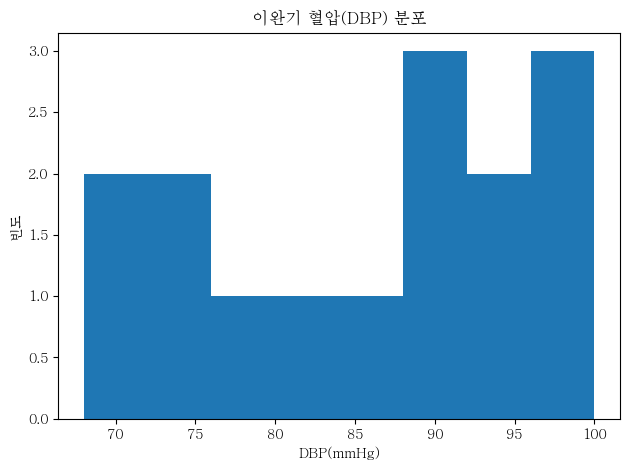

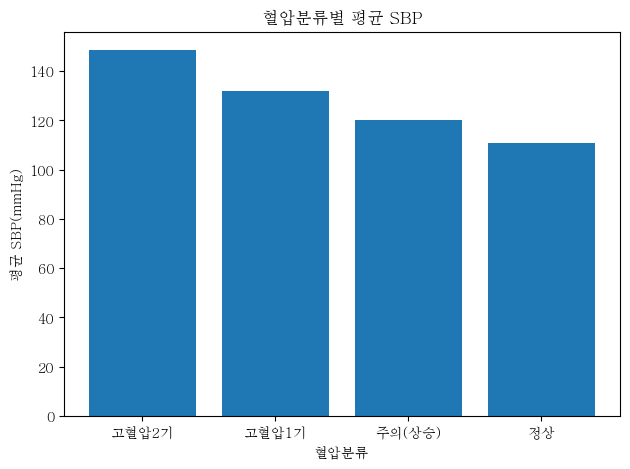

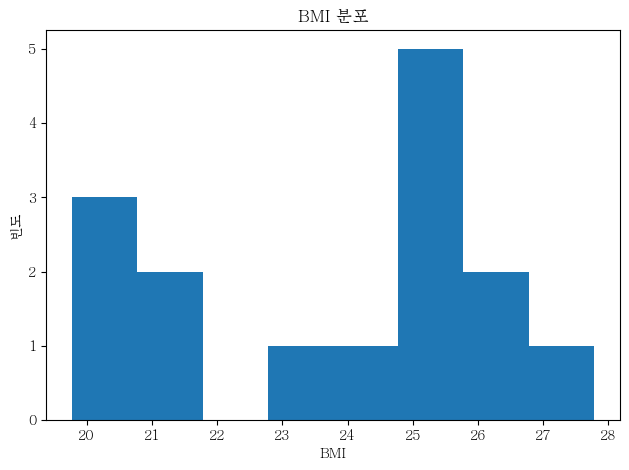

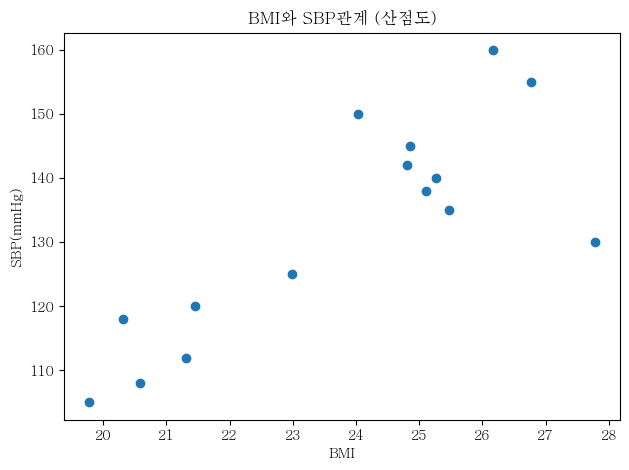

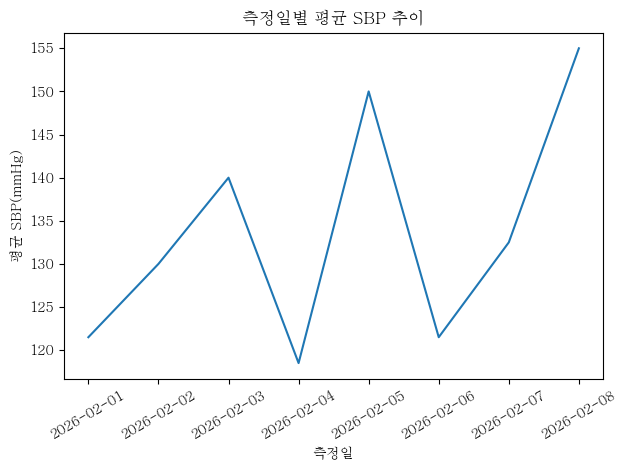

In [21]:
# 한국어 안나옴 -> 폰트 설정
import matplotlib.font_manager as fm

# 원하는 폰트 파일 경로 문자열로 입력
# C:\\Windows\\Fonts 경로 들어가서 한국어 폰트 우클릭, 속성 들어가서 이름 넣기
font_location = "C:\\Windows\\Fonts\\batang.ttc"
# 지정한 폰트 파일 경로에서 폰트 추출
fontname = fm.FontProperties(fname=font_location).get_name()
# matplotlib의 전역 폰트 설정 변경
plt.rc('font', family=fontname)


# 5 시각화

# 5-1 혈압(SBP/DBP) 분포 히스토그램
# 히스토그램
# 숫자 데이터가 어느 구간에 얼마나 많이 모여있는지 보여주는 그래프
# bins가 크면 나뉘는 구간이 촘촘함(구간 수에 따라 그래프 모양이 달라짐)

# 새로운 그래프 공간 생성
plt.figure()
# 구간 설정 (hist -> 히스토그램 그래프)
plt.hist(df["SBP(수축기)"], bins=8)
# 그래프 제목
plt.title("수축기 혈압(SBP) 분포")
# 가로측 의미 설명
plt.xlabel("SBP(mmHg)")
# 세로축 의미 설정
plt.ylabel("빈도")
# 글자가 잘리지 않게 자동 정렬
plt.tight_layout()
# 그래프 출력
plt.show()

plt.figure()
plt.hist(df["DBP(이완기)"], bins=8)
plt.title("이완기 혈압(DBP) 분포")
plt.xlabel("DBP(mmHg)")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()

# 5-2 혈압분류별 평균 SBP 막대 그래프
# 혈압분류로 그룹화 해서 SBP(수축기) 컬럼 선택 후 평균냄
bp_sbp_mean = df.groupby("혈압분류")["SBP(수축기)"].mean().sort_values(ascending=False) # 내림차순
plt.figure()
plt.bar(bp_sbp_mean.index, bp_sbp_mean.values)
plt.title("혈압분류별 평균 SBP")
plt.xlabel("혈압분류")
plt.ylabel("평균 SBP(mmHg)")
# x축 글자가 길때 x축 눈금
# x축 글자를 30도 정도 기울여라
# plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# 5-3 BMI 분포 히스토그램
plt.figure()
plt.hist(df["BMI"], bins=8)
plt.title("BMI 분포")
plt.xlabel("BMI")
plt.ylabel("빈도")
plt.tight_layout()
plt.show()


# 5-4 산점도 : BMI vs SBP
# 산점도 : 2개의 숫자 변수 관계를 점(dot)으로 표현한 그래프
plt.figure()
plt.scatter(df["BMI"], df["SBP(수축기)"])
plt.title("BMI와 SBP관계 (산점도)")
plt.xlabel("BMI")
plt.ylabel("SBP(mmHg)")
plt.tight_layout()
plt.show()


# 5-5 측정일 기준 SBP 추이(날짜별 편균)
date_sbp = df.groupby("측정일")["SBP(수축기)"].mean()
plt.figure()
plt.plot(date_sbp.index, date_sbp.values)
plt.title("측정일별 평균 SBP 추이")
plt.xlabel("측정일")
plt.xticks(rotation=30)
plt.ylabel("평균 SBP(mmHg)")
plt.tight_layout()
plt.show()
